# **ІАД**

## **Лаб 3. Кацуба Тимофій КН-42**

In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# завантаження даних
file_path = '/Users/timofijmazestik/Downloads/SpotifyFeatures.csv' 
df = pd.read_csv(file_path)

# Виводимо перші 5 рядків, щоб перевірити
display(df.head())

# визначаємо ознаки для аналізу
# беремо аудіо-характеристики[cite: 15]. Popularity окремо для фільтрації
features_to_scale = [
    'danceability', 'energy', 'loudness', 'speechiness', 
    'acousticness', 'instrumentalness', 'liveness', 'valence', 
    'tempo', 'duration_ms'
]

# видаляємо можливі пропуски
df = df.dropna(subset=features_to_scale + ['popularity']).copy()

# стандартизація числових ознак [cite: 20]
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[features_to_scale] = scaler.fit_transform(df[features_to_scale])

#фільтрація для візуалізації [cite: 21]
# створюємо окремий DataFrame, де популярність >= 85
df_popular = df_scaled[df_scaled['popularity'] >= 85].copy()

# Виводимо розмірності [cite: 23]
print(f"Розмірність повного датасету (для навчання моделі): {df_scaled.shape}")
print(f"Розмірність відфільтрованого датасету (тільки популярні, для графіків): {df_popular.shape}")

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


Розмірність повного датасету (для навчання моделі): (232725, 18)
Розмірність відфільтрованого датасету (тільки популярні, для графіків): (417, 18)


Обчислення K-Means для різних k.
Обчислення завершено.


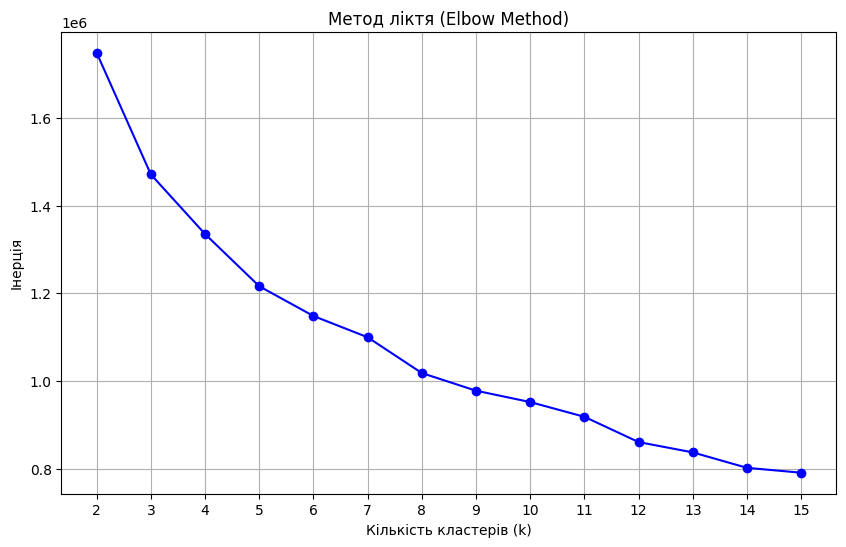

In [8]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# список для збереження значень інерції (суми квадратів відстаней)
inertia = []

# діапазон від 2 до 15 кластерів
K_range = range(2, 16)

print("Обчислення K-Means для різних k.")

for k in K_range:
    # random_state потрібен, щоб результати не стрибали при перезапусках
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    
    # Навчаємо модель на датасеті (вик. лише відібрані та стандартизовані колонки)
    kmeans.fit(df_scaled[features_to_scale])
    
    inertia.append(kmeans.inertia_)

print("Обчислення завершено.")

# візуал. методу ліктя
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='-', color='b')
plt.title('Метод ліктя (Elbow Method)')
plt.xlabel('Кількість кластерів (k)')
plt.ylabel('Інерція')
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [9]:
# задаємо кількість кластерів
optimal_k = 5 

# ініціал. та навчаємо фінальну модель
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')

# fit_predict відразу і навчає, і видає номери кластерів
clusters = kmeans_final.fit_predict(df_scaled[features_to_scale])

# додаємо мітки кластерів у наші таблиці
df_scaled['cluster'] = clusters
df['cluster'] = clusters # додаємо і в оригінальну таблицю, це знадобиться для аналізу в Блоці 5

# відфільтрований датасет, тепер він має колонку cluster
df_popular = df_scaled[df_scaled['popularity'] >= 85].copy()

# скільки треків потрапило в кожен кластер
print(f"Розподіл треків по {optimal_k} кластерах (на всіх даних):")
print(df['cluster'].value_counts().sort_index())

Розподіл треків по 5 кластерах (на всіх даних):
cluster
0    65971
1    45212
2    10119
3    27663
4    83760
Name: count, dtype: int64


Виконання зниження розмірності (PCA)
Графік


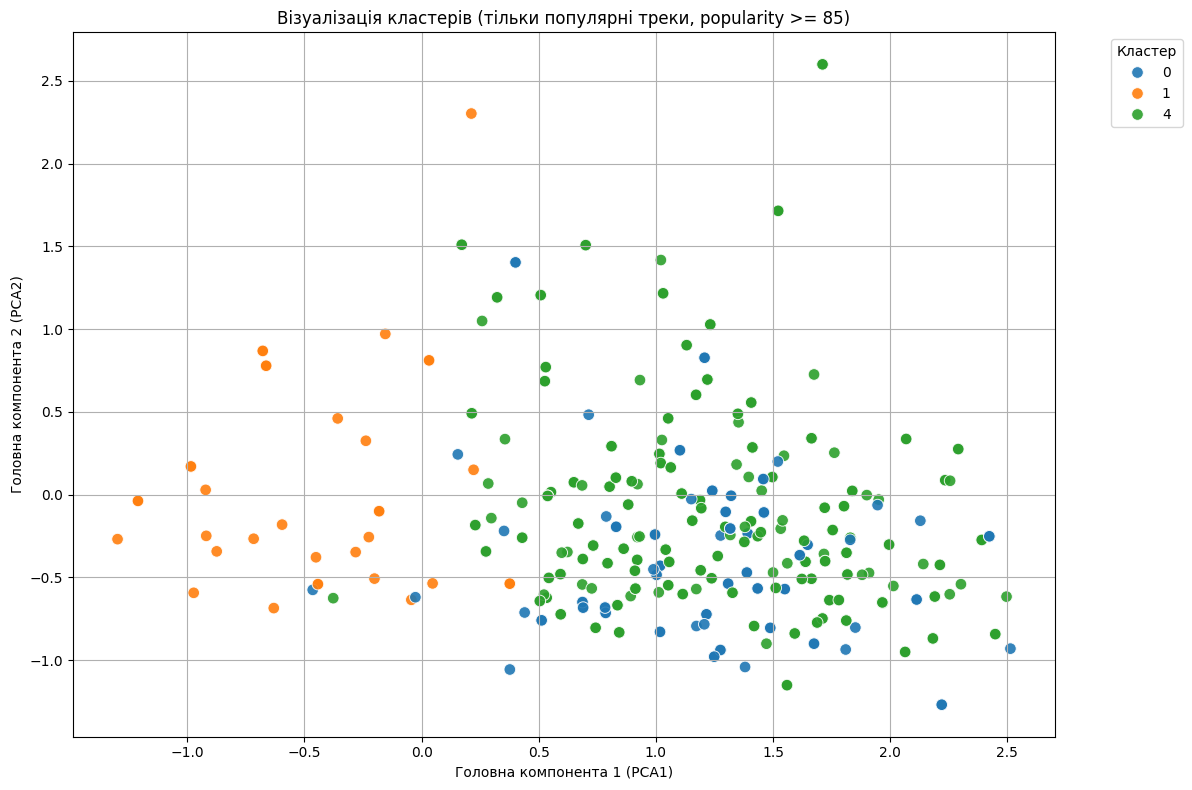

In [10]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

print("Виконання зниження розмірності (PCA)")

# ініціалізуємо PCA для 2 вим.
pca = PCA(n_components=2)

# навчаємо PCA на всіх даних, щоб алгоритм зрозумів загальну структуру
pca.fit(df_scaled[features_to_scale])

# стискаємо лише популярні треки для візуалізації
popular_pca = pca.transform(df_popular[features_to_scale])

# додаємо 2 нові координати  до нашої таблиці популярних треків
df_popular['PCA1'] = popular_pca[:, 0]
df_popular['PCA2'] = popular_pca[:, 1]

print("Графік")

# візуал
plt.figure(figsize=(12, 8))

# seaborn для малювання точок з розфарбуванням по кластерах
sns.scatterplot(
    x='PCA1', 
    y='PCA2', 
    hue='cluster', # Колір залежить від колонки cluster
    palette='tab10', # Набір кольорів
    data=df_popular, 
    alpha=0.9, # Прозорість точок
    s=70 # Розмір точок
)

plt.title('Візуалізація кластерів (тільки популярні треки, popularity >= 85)')
plt.xlabel('Головна компонента 1 (PCA1)')
plt.ylabel('Головна компонента 2 (PCA2)')
plt.legend(title='Кластер', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

Аналіз середніх значень характеристик по кластерах (на всіх даних)

Реальні середні значення по кластерах:


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
cluster,,,,,,,,,,
0,0.500928,0.762673,-5.993338,0.091714,0.098405,0.095144,0.244015,0.418501,140.707700,245325.797563
1,0.510178,0.332459,-12.021726,0.066452,0.699785,0.070882,0.176970,0.341187,111.671316,225305.604862
2,0.562637,0.663933,-11.984641,0.878258,0.789658,0.001124,0.729387,0.414089,98.059067,244106.470106
3,0.289535,0.164189,-20.939311,0.045628,0.845824,0.733810,0.147748,0.150745,102.327341,264710.885081
4,0.706768,0.671805,-7.016739,0.106266,0.194056,0.056365,0.172769,0.650378,110.189873,221527.347564


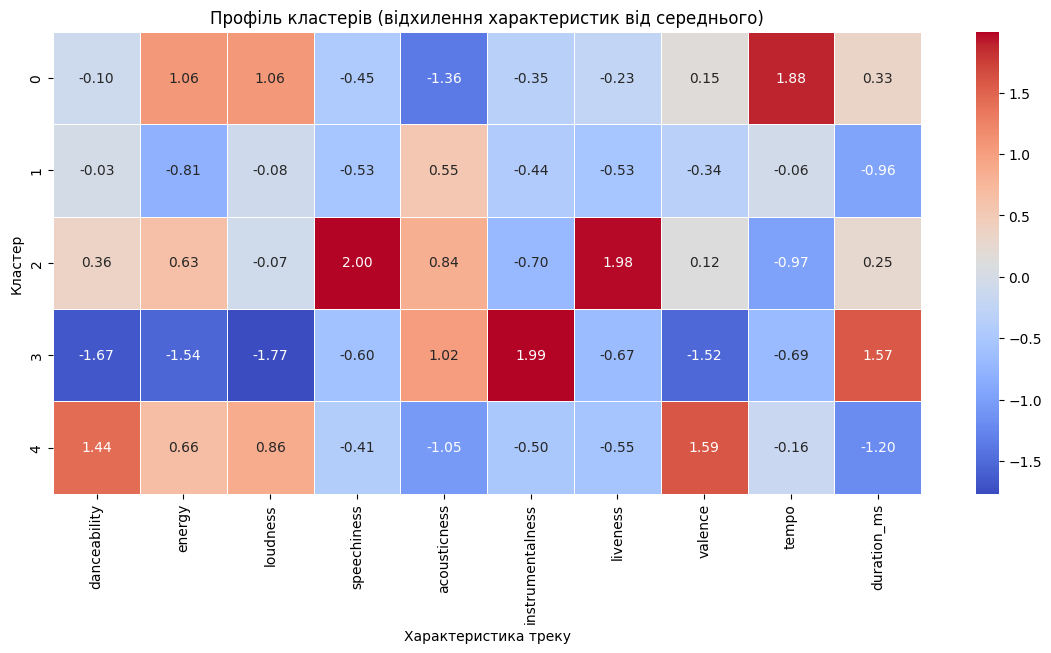

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Аналіз середніх значень характеристик по кластерах (на всіх даних)")

# рахуємо середні значення для кожного кластера.
# використовуємо оригінальний датафрейм (df), а не масштабований (df_scaled)
cluster_summary = df.groupby('cluster')[features_to_scale].mean()

# Виводимо звичайну таблицю
print("\nРеальні середні значення по кластерах:")
display(cluster_summary)

# стандартизуємо ці середні значення, щоб кольори були контрастними
from sklearn.preprocessing import StandardScaler
scaler_heatmap = StandardScaler()

cluster_summary_scaled = pd.DataFrame(
    scaler_heatmap.fit_transform(cluster_summary), 
    columns=cluster_summary.columns, 
    index=cluster_summary.index
)

plt.figure(figsize=(14, 6))
sns.heatmap(cluster_summary_scaled, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Профіль кластерів (відхилення характеристик від середнього)')
plt.ylabel('Кластер')
plt.xlabel('Характеристика треку')
plt.show()